In [1]:
import os
import torch
from deeplsd.models.deeplsd_inference import DeepLSD
from line_understanding.pipeline import process_image_pipeline, plot_pipeline_results
from line_understanding.json_saver import save_lines_to_json 


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location='cpu', weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()



data/DSC_0442/image.jpg
data/DSC_0442/depth.png
data/DSC_0442/meta.json


[04/03/2025 15:08:34 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


(1365, 2048, 3)
(1365, 2048)
(1365, 2048, 3)
(1365, 2048, 3)


/Users/marvin/Documents/ETHZ/MA4/3DVision/repo/DeepLSD/notebooks/line_understanding/utility_methods.py:218: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-lam * (x - tau)))


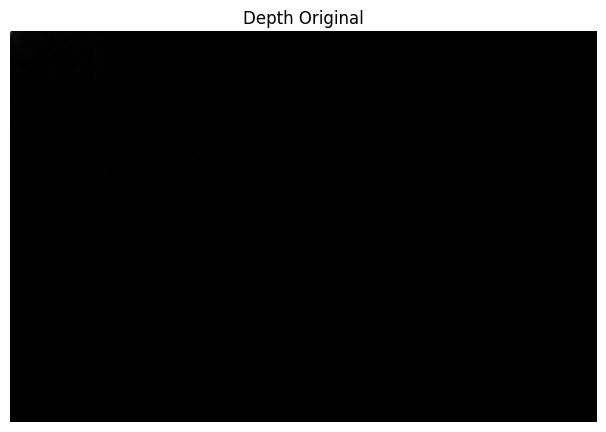

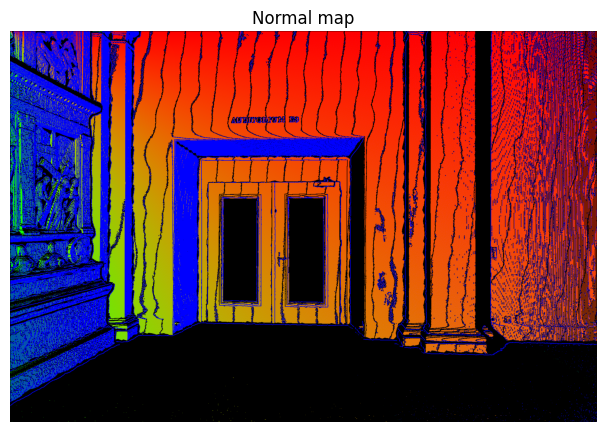

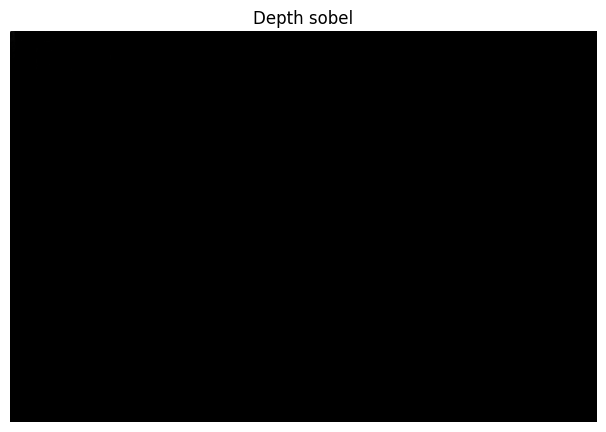

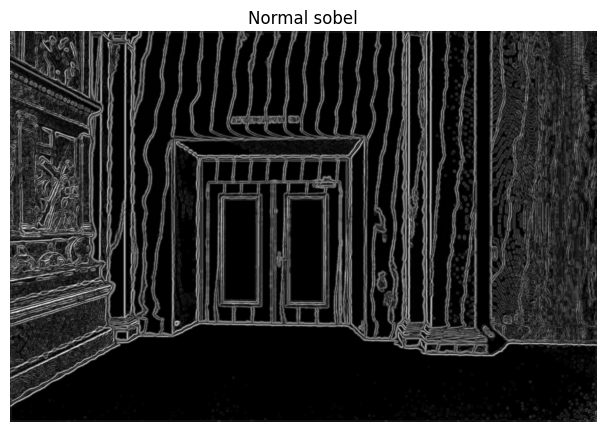

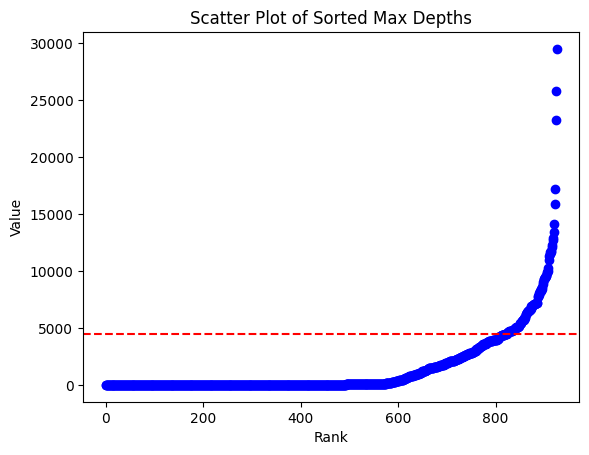

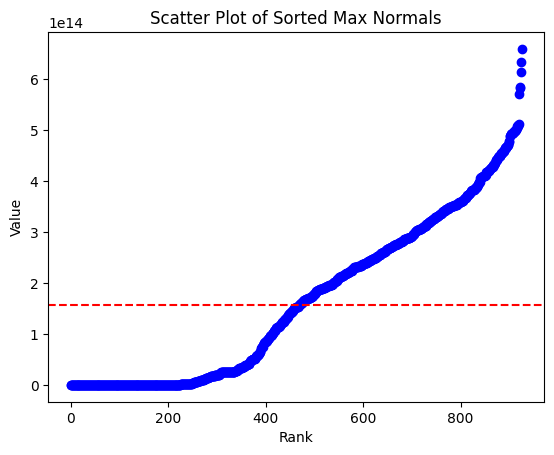

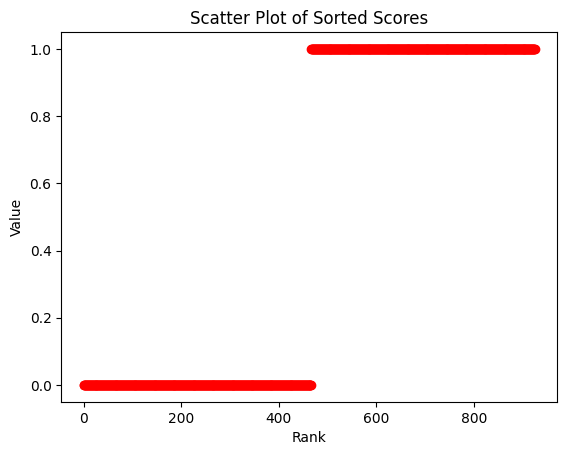

[Neighborhood Method] DSC_0442: Detected 926 lines; 459 structural.


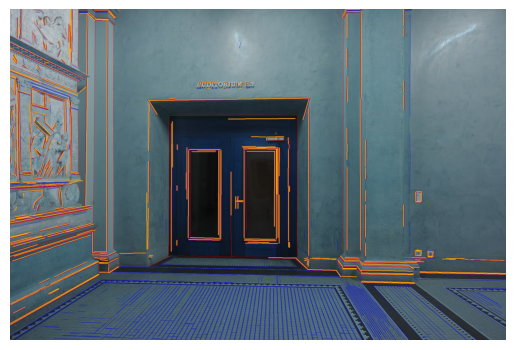

World_coordinates 1365 2048
start hdbscan


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start dilation


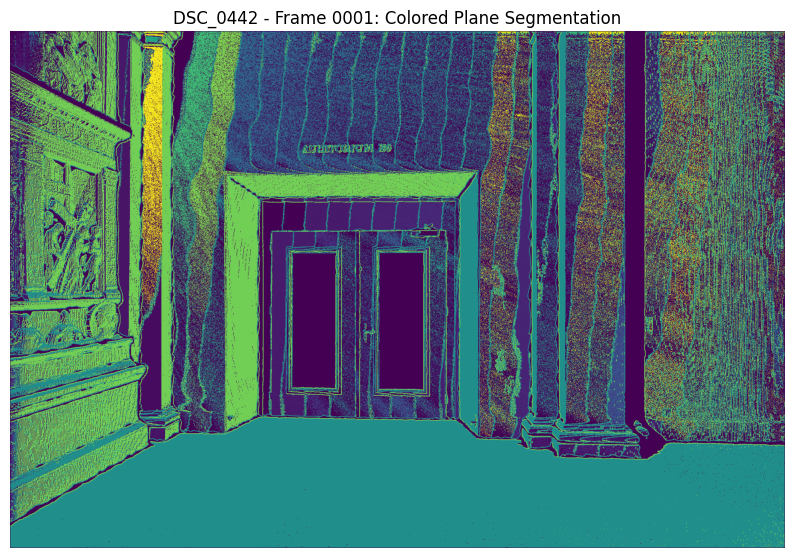

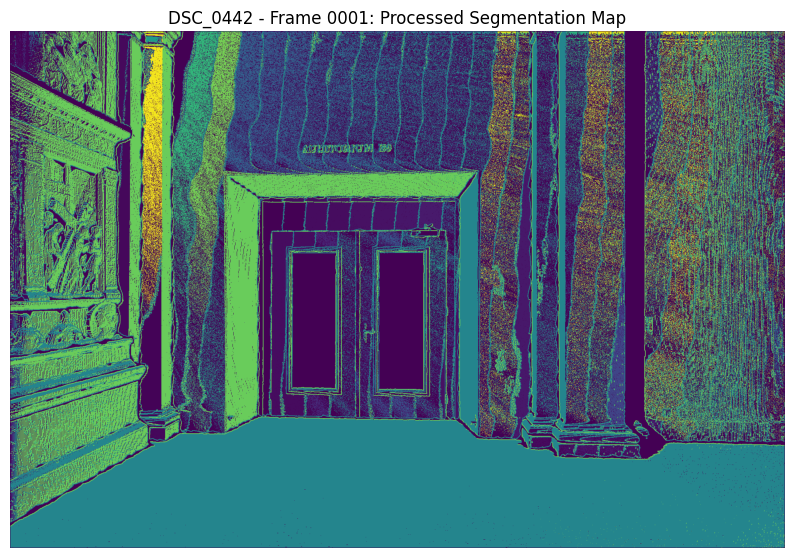

Unique Labels: [-1, 45, 46, 47, 50, 75, 76, 84, 93, 106, 111, 112, 113, 133, 242, 243, 312, 1314, 1436, 1528, 1534, 1725, 1856, 1859, 2229, 2381, 2502, 2636, 2702, 2745, 2910, 3013, 3190, 3739, 3978, 4101, 4551, 4569, 4570, 4700, 4806, 5142, 5226, 5303, 5615, 5749, 5751, 6131, 6231, 6673, 6675, 7325, 7489, 7551, 9012, 10825, 11449, 14888, 67452, 76627, 105525, 107187, 136699, 178629, 208634, 208975, 227615]
Number of Clusters: 67


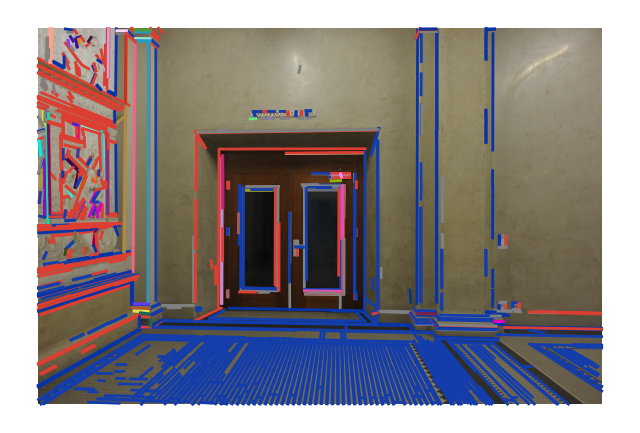

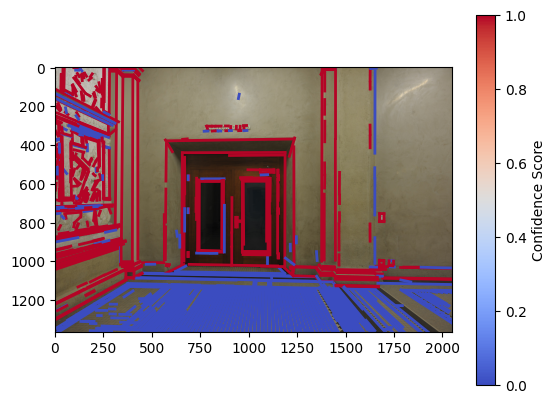

data/DSC_0455/image.jpg
data/DSC_0455/depth.png
data/DSC_0455/meta.json


[04/03/2025 15:18:57 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


(1365, 2048, 3)
(1365, 2048)
(1365, 2048, 3)
(1365, 2048, 3)


/Users/marvin/Documents/ETHZ/MA4/3DVision/repo/DeepLSD/notebooks/line_understanding/utility_methods.py:218: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-lam * (x - tau)))


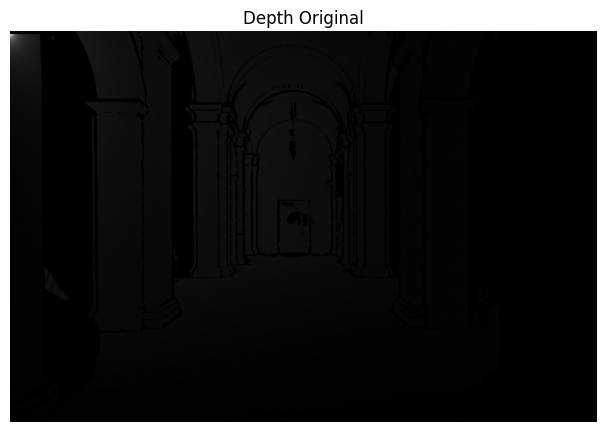

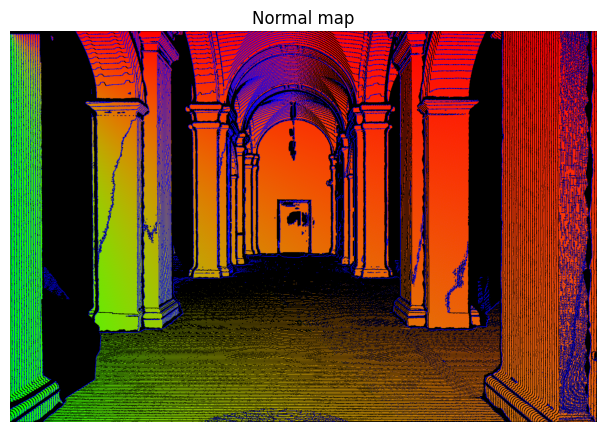

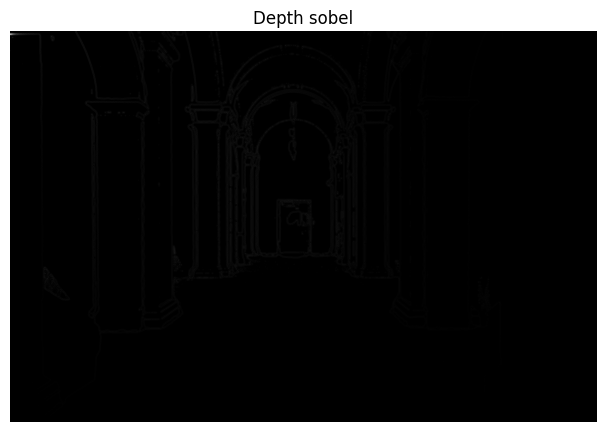

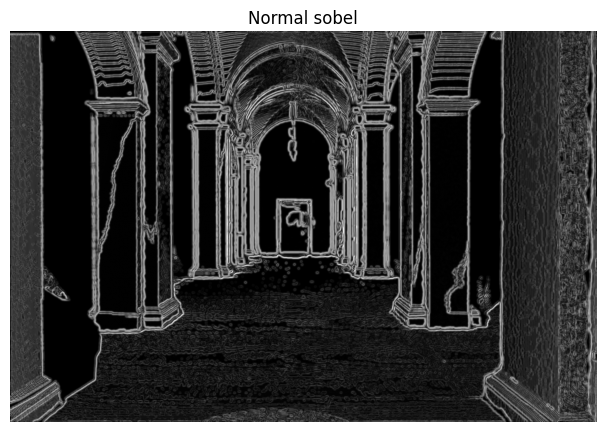

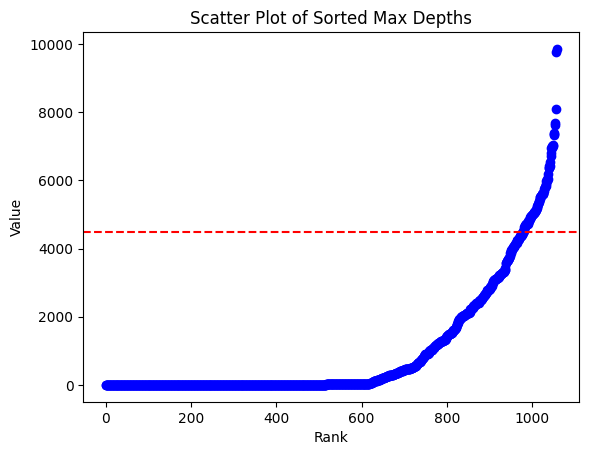

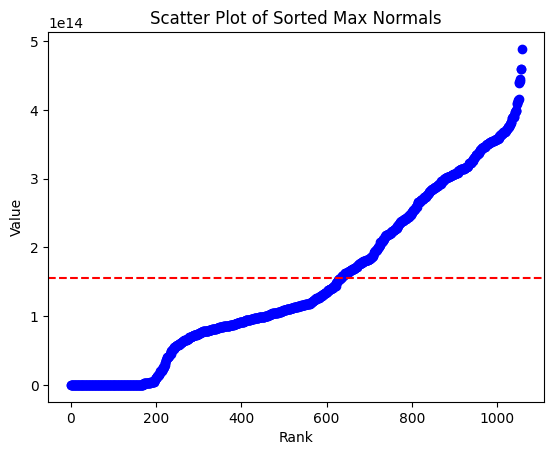

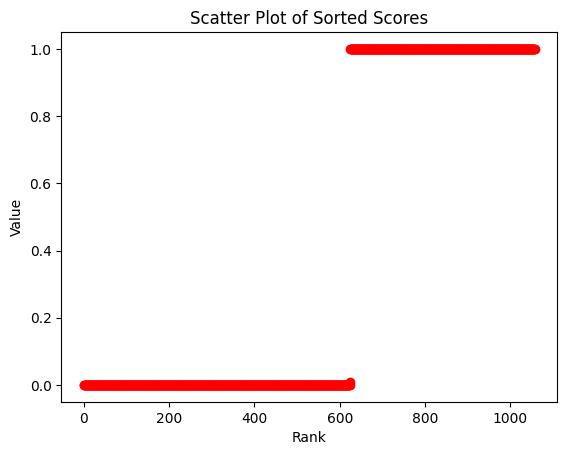

[Neighborhood Method] DSC_0455: Detected 1058 lines; 433 structural.


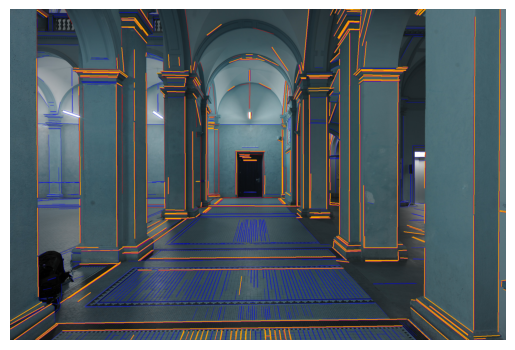

In [ ]:
#OLD
frame_str = "0001"
desired_images = [
    "DSC_0442",
    "DSC_0455",
    "DSC_0239",
    "DSC_0249",
    
]

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    # processed_data = process_image_pipeline(image_id, frame_str, net, device, depth_thresh=0.15*1e7, normal_thresh=(1.25 * 1e7)**2, cluster_selection_epsilon=0.0001, 
    #     min_cluster_size=200, dataset="moge_gt")
    processed_data = process_image_pipeline(image_id, frame_str, net, device, depth_thresh=4500, normal_thresh=(1.25 * 1e7)**2, cluster_selection_epsilon=0.002, 
        min_cluster_size=10, dataset="moge_gt")
    if processed_data is not None:
        plot_pipeline_results(processed_data, frame_str)
        

data/DSC_0442/image.jpg
data/DSC_0442/depth.png
data/DSC_0442/meta.json


/Users/marvin/Documents/ETHZ/MA4/3DVision/repo/DeepLSD/notebooks/line_understanding/utility_methods.py:218: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-lam * (x - tau)))


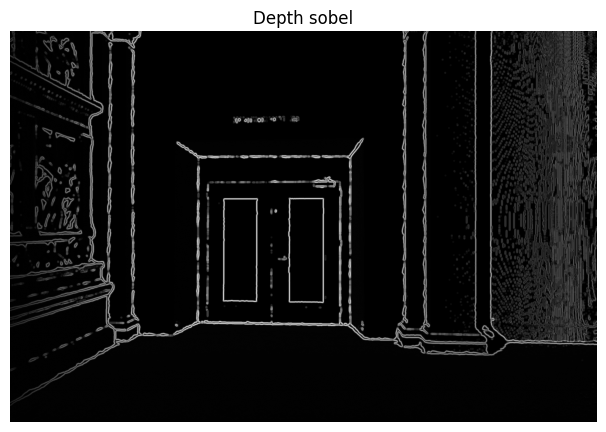

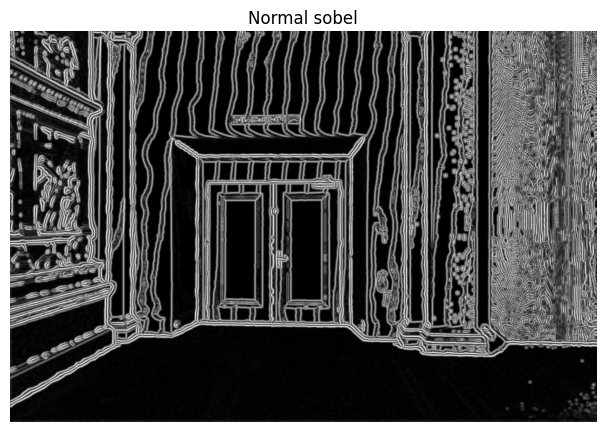

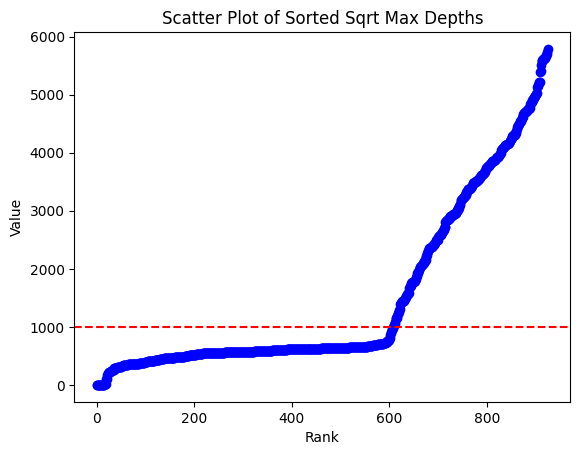

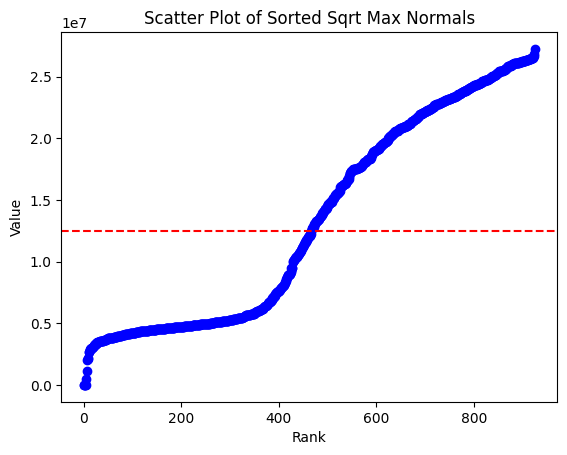

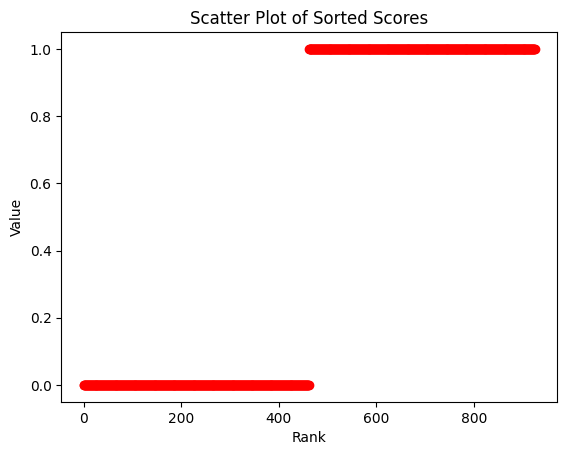

[Neighborhood Method] DSC_0442: Detected 926 lines; 464 structural.


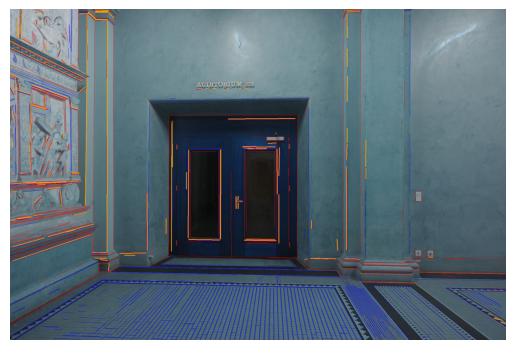

start hdbscan


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start nearestneighbors


In [ ]:
#OLD
frame_str = "0001"
desired_images = [
    "DSC_0442",
    "DSC_0455",
    "DSC_0239",
    "DSC_0249",
    
]

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    processed_data = process_image_pipeline(image_id, frame_str, net, device, depth_thresh=1000, normal_thresh=1.25 * 1e7, cluster_selection_epsilon=0.001, 
        min_cluster_size=10, dataset="moge_gt")
    if processed_data is not None:
        plot_pipeline_results(processed_data, frame_str)
        
    # processed_data = process_image_pipeline_2(image_id, frame_str, net, device)
    # if processed_data is not None:
    #     plot_pipeline_results(processed_data, frame_str)
    
    
